In [30]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from IPython.display import display
import sklearn
from sklearn import set_config
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import CategoricalNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate,cross_val_predict
from sklearn.metrics import (PrecisionRecallDisplay, ConfusionMatrixDisplay,make_scorer,
recall_score, precision_score, precision_recall_curve)
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import shap

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    KBinsDiscretizer,
    FunctionTransformer,
    LabelEncoder
)
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

set_config(transform_output="pandas") # For easier debugging with DataFrames and because we work with catecory data type

In [2]:
df = pd.read_parquet('montgomery_crash_reporting_processed.parquet')

# feature selctor

In [3]:
feature_summary = pd.DataFrame({
    'Feature': df.columns,
    'Unique_Values': [df[col].nunique() for col in df.columns],
    'Data_Type': [df[col].dtype for col in df.columns]
})
feature_summary

,Feature,Unique_Values,Data_Type
0,agency_name,6,category
1,acrs_report_type,3,category
2,hit_run,2,Int64
3,route_type,5,category
4,distance,5834,float64
5,at_fault,3,category
6,collision_type,6,category
7,weather,7,category
8,surface_condition,4,category
9,light,6,category


In [3]:
def create_cyclic_features(df):
    """
    Transforms temporal features into sine/cosine components.
    Fixes the TypeError by explicitly casting mapped values to float.
    """
    df = df.copy()
    
    # --- 1. Basic numeric cycles (Hour, Month, Day of week) ---
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'].astype(float) / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'].astype(float) / 24)
    
    df['month_sin'] = np.sin(2 * np.pi * (df['month'].astype(float) - 1) / 12)
    df['month_cos'] = np.cos(2 * np.pi * (df['month'].astype(float) - 1) / 12)
    
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'].astype(float) / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'].astype(float) / 7)
    
    # --- 2. Season cycle ---
    # Ensure all possible values in your data are covered by the map
    season_map = {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Autumn': 3}
    if 'season' in df.columns:
        # Crucial fix: .astype(float) after mapping
        season_num = df['season'].map(season_map).astype(float)
        df['season_sin'] = np.sin(2 * np.pi * season_num / 4)
        df['season_cos'] = np.cos(2 * np.pi * season_num / 4)
    
    # --- 3. Time of day cycle ---
    # Double-check if 'Mid_day' should be 'Afternoon' based on your unique values
    time_map = {'Morning': 0, 'Mid_day': 1, 'Evening': 2, 'Night': 3}
    if 'time_of_day' in df.columns:
        # Crucial fix: .astype(float) after mapping
        time_num = df['time_of_day'].map(time_map).astype(float)
        df['time_sin'] = np.sin(2 * np.pi * time_num / 4)
        df['time_cos'] = np.cos(2 * np.pi * time_num / 4)
    
    
    return df

In [4]:
# ================
# FEATURE GROUPS 
# =================

TARGET_COL = 'acrs_report_type'

# --- Numeric Features ---
# includes the generated cyclic sine/cosine features
NUMERIC_FEATS = [
    'distance', 
    'crash_year',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
    'dow_sin', 'dow_cos',
    'season_sin', 'season_cos',
    'time_sin', 'time_cos'
]

# --- Cyclic Features (Before transformation) ---
# These will be passed through the create_cyclic_features function
CYCLIC_FEATS = ['hour', 'month', 'day_of_week', 'season', 'time_of_day']

# --- Binary Features (0/1) ---
BINARY_FEATS = [
    'is_weekend',
    'is_holiday',
    'is_two_way', # Derivative of road_division_cat
    'driver_substance_abuse',
    # Road Grade Binary Indicators (Handled manually in preprocessing)
    'road_grade_Downhill', 'road_grade_Hillcrest', 'road_grade_Level', 
    'road_grade_On_Bridge', 'road_grade_Other', 'road_grade_Sag', 
    'road_grade_Uphill', 'road_grade_Not_Relevant',
    # Road Alignment Binary Indicators
    'road_alignment_Curve_Left', 'road_alignment_Curve_Right', 
    'road_alignment_Other', 'road_alignment_Straight', 
    'road_alignment_Not_Relevant'
]

# --- Nominal Categorical Features ---
# ther is redundancy with 'road_grade_cat', 'road_alignment_cat' and 'road_division_cat', it will be handled in preprocessing
CAT_FEATS = [
    'route_type', 
    'weather', 
    'junction', 
    'road_condition',
    'light', 
    'surface_condition', 
    'road_grade_cat',    
    'road_alignment_cat',
    'road_division_cat', 
    'division_type', # Derivative of road_division_cat
    'division',  # Derivative of road_division_cat
    'left_turn', # Derivative of road_division_cat
    'traffic_control'
]


how its lock at hi level

In [ ]:
feature_groups = {
    'Numeric': len(NUMERIC_FEATS),
    'Binary': len(BINARY_FEATS),
    'Categorical': len(CAT_FEATS)
}

target_counts = df[TARGET_COL].value_counts()


fig, ax = plt.subplots(1, 2, figsize=(16, 8))

colors_feat = ["#3f5370", "#457b9d", "#078778"]
ax[0].pie(feature_groups.values(), labels=feature_groups.keys(), autopct='%1.1f%%', 
          startangle=140, pctdistance=0.85, colors=colors_feat, 
          wedgeprops={'width': 0.3, 'edgecolor': 'w'})

ax[0].set_title('Feature Groups Distribution', fontsize=15, pad=20, fontweight='bold')


colors_target = plt.cm.Pastel1.colors
ax[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', 
          startangle=140, pctdistance=0.85, colors=colors_target, 
          wedgeprops={'width': 0.3, 'edgecolor': 'w'})

ax[1].set_title(f'Target Distribution\n({TARGET_COL})', fontsize=15, pad=20, fontweight='bold')

plt.tight_layout()
plt.show()

# Tree Models (CB, LGBM, RF)

In [5]:
# ============================================================
# FEATURE SELECTION 
# Strategy: Use parent categorical columns instead of binary 
# derivatives because tree models can split optimally on categories rather
# than fragmented binary indicators.
# ============================================================

# -- Categorical --
tree_cat_selection = [
    'route_type', 'weather', 'junction', 'road_condition', 'light',
    'surface_condition', 
    'road_grade_cat', 
    'road_alignment_cat', 
    'road_division_cat', 
    'traffic_control'
]

# -- Binary --
tree_bin_selection = [c for c in BINARY_FEATS if not (
    c.startswith('road_grade_') or 
    c.startswith('road_alignment_') or 
    c == 'is_two_way')] # Derivative of road_division_cat

native_preprocessor = ColumnTransformer(
    transformers=[
        # Numeric/Binary: keep NaNs; CatBoost handles missing values natively
        # Categorical: encode missingness explicitly as "MISSING"
        ('num', 'passthrough', NUMERIC_FEATS),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='MISSING')),
            ('cast', FunctionTransformer(lambda x: x.astype('category'), validate=False))
        ]), tree_cat_selection), 
        ('bin', 'passthrough', tree_bin_selection)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

## CatBoost

In [6]:
cb_pipeline = Pipeline([
     ('preprocessor', native_preprocessor),
    ('model', CatBoostClassifier(
        cat_features = tree_cat_selection,
        auto_class_weights='Balanced', # Increases penalty for mistakes on rare classes
        verbose=50,
        allow_writing_files=False,
        loss_function='MultiClass', # penalizes the model for being "confident and wrong" + softmax
        random_state=42
    ))
])

## LightGBM

In [7]:
lgbm_pipeline = Pipeline([
    ('preprocessor', native_preprocessor),
    ('model', LGBMClassifier(
        class_weight='balanced', # Increases penalty for mistakes on rare classes
        verbose=10,
        n_jobs=-1,
        categorical_feature='auto',
        objective='multiclass', # multi-class classification, softmax
        metric='multi_logloss', # penalizes the model for being "confident and wrong"
        importance_type='gain', # Better for interpretation and more fit to our goal
        random_state=42
    ))
])

## Random Forest

In [8]:
rf_preprocessor = ColumnTransformer(
    transformers=[
        # Numeric: Simple median imputation
        ('num', SimpleImputer(strategy='median'), NUMERIC_FEATS), 
        
        # Binary: Imputing missing values (RF fails on NaNs in sklearn)
        ('bin', SimpleImputer(strategy='most_frequent'), tree_bin_selection),

        # Categorical: All tree categories via OHE
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
        ]), tree_cat_selection)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

rf_pipeline = Pipeline([
    ('preprocessor', rf_preprocessor),
    ('model', RandomForestClassifier(
        class_weight='balanced',  # importent for rare classes

        n_estimators=200,      
        max_depth=15,          # Limit depth to prevent Overfitting on noisy data
        min_samples_split=10,  # Require at least 10 samples to split a node
        min_samples_leaf=4,    # helps smooth the model against noise
        n_jobs=-1,         
        random_state=42,
        verbose=0           
    ))
])

# Logistic Regression

In [9]:
# Categorical: here we prefer to work with the features which derivative
# of the catgory features, as they may provide clearer signals for LR.
lr_cat_selection = [c for c in CAT_FEATS if c not in [
    'road_grade_cat', 
    'road_alignment_cat', 
    'road_division_cat', 
    'surface_condition'
]]


lr_preprocessor = ColumnTransformer(
    transformers=[
        # Numeric: scale + impute
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()) 
        ]), NUMERIC_FEATS),

        ('bin', SimpleImputer(strategy='most_frequent'), BINARY_FEATS),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), lr_cat_selection)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)


lr_pipeline = Pipeline([
    ('preprocessor', lr_preprocessor),
    ('model', LogisticRegression(
        # --- Solver & Convergence ---
        solver='lbfgs',          # The standard engine (Stable, handles Multiclass, supports L2, suitable for our data size)
        max_iter=500,            # Changed from default (100) to ensure convergence on imbalanced data
        
        # --- Class Imbalance ---
        class_weight='balanced', # Forces the model to give more weight to rare classes, maybe we will manually weight later
        
        # --- Technical ---
        n_jobs=-1,             
        random_state=42          
        
        # --- Hidden Defaults ---
        # penalty='l2' (Standard Ridge Regularization is on)
        # C=1.0 (Moderate regularization strength)
        # multi_class='auto' (Automatically selects Softmax/Multinomial)
    ))
])

# Categorial Naive Bayes

In [13]:
# NB is sensitive to correlated features (double-counting). 
# also he asumes indrependent features so we prfer the "father" features and not their derivatives.
# We use the clean "Tree" selection.

nb_cat_selection = tree_cat_selection + ['crash_year']  # Moving discrete numeric to categorical for better NB performance
nb_num_feats = [c for c in NUMERIC_FEATS if c != 'crash_year']


nb_preprocessor = ColumnTransformer(
    transformers=[
        # --- Discretizing Numeric Features ---
        # CategoricalNB requires discrete categories. 
        # Quantile strategy ensures bins have equal number of samples.
        ('num_binned', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('discretizer', KBinsDiscretizer(
                n_bins=15, 
                encode='ordinal', 
                strategy='quantile'
            ))
        ]), nb_num_feats),
        
        # --- Binary Features ---
        # Already discrete (0/1), just need to ensure no NaNs.
        ('bin', SimpleImputer(strategy='most_frequent'), tree_bin_selection),
        
        # --- Categorical Features ---
        # Shifted to ensure all values are non-negative integers.
        ('cat_all', Pipeline([
            ('to_str', FunctionTransformer(lambda x: x.astype(str), validate=False)),
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('ordinal', OrdinalEncoder(
                handle_unknown='use_encoded_value',
                unknown_value=-1 
            )),
            ('shift', FunctionTransformer(func=lambda x: x + 1, validate=False
            ))
        ]), nb_cat_selection)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

nb_pipeline = ImbPipeline([
    ('preprocessor', nb_preprocessor),
    
    # NB does not have a 'class_weight' parameter in sklearn.
    # Resampling is necessary to handle the minority classes.
    ('resampler', RandomOverSampler(
        sampling_strategy='not majority', 
        random_state=42
    )),
    
    ('model', CategoricalNB(
        alpha=0.5  # Laplace smoothing to avoid zero probabilities. high -> more wheigt to prior. low -> more weight to data.
    ))
])

# comparing the models

In [11]:
y = df[TARGET_COL]
X_raw = df.drop(columns=[TARGET_COL])

X = create_cyclic_features(X_raw) # creates the hour_sin, month_cos etc. features we defined

# --- Stratified Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Target Encoding ---
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

target_names = list(le.classes_)

counts = Counter(y_train_encoded)
total = len(y_train_encoded)

# Building the summary table
summary_data = []
for i, class_name in enumerate(le.classes_):
    count = counts[i]
    summary_data.append({
        'Label': i,
        'Class Name': class_name,
        'Count': f"{count:,}",
        'Percentage': f"{(count/total)*100:.2f}%"
    })

# Identifying the minority class (index and name) for the benchmark
minority_class_val = min(counts, key=counts.get)
minority_class_name = le.classes_[minority_class_val]

print("Target Variable Summary (Train Set):")

display(pd.DataFrame(summary_data))

print(f"Target Minority Class: {minority_class_val} ({minority_class_name})\n")

Target Variable Summary (Train Set):


,Label,Class Name,Count,Percentage
0,0,Fatal Crash,295,0.32%
1,1,Injury Crash,"31,601",33.81%
2,2,Property Damage Crash,"61,577",65.88%


Target Minority Class: 0 (Fatal Crash)



In [14]:
def run_benchmark(pipelines_dict, X_train, y_train, X_test, y_test, minority_class_idx, target_names):
    """
    Evaluates multiple pipelines and returns a performance leaderboard.
    """
    results = []
    
    for name, pipe in pipelines_dict.items():
        print(f"Processing: {name}...")
        
        # Training
        start_time = time.time()
        pipe.fit(X_train, y_train)
        train_time = time.time() - start_time
        
        # Prediction
        y_pred = pipe.predict(X_test)
        
        # Global Metrics
        f1_macro = f1_score(y_test, y_pred, average='macro')
        bal_acc = balanced_accuracy_score(y_test, y_pred)
        
        # Per-class Metrics
        # Using labels=range(len(target_names)) to match our 0, 1, 2 encoding
        prec, rec, f1_per_class, _ = precision_recall_fscore_support(
            y_test, y_pred, labels=range(len(target_names)), zero_division=0
        )
        
        # Store results for the specific minority class index
        results.append({
            'Model': name,
            'F1 Macro': round(f1_macro, 4),
            'Balanced Acc': round(bal_acc, 4),
            'Min. Recall': round(rec[minority_class_idx], 4),
            'Min. Precision': round(prec[minority_class_idx], 4),
            'Min. F1': round(f1_per_class[minority_class_idx], 4),
            'Time (s)': round(train_time, 2)
        })
        
        # Intermediate output for tracking with CATEGORY NAMES
        print(f"\n Classification Report for {name}:")
        print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0, digits=3))
        print("-" * 60)

    # Leaderboard creation
    leaderboard = pd.DataFrame(results).sort_values('F1 Macro', ascending=False)
    return leaderboard

# ======================================================
# 4. EXECUTION
# ======================================================
pipelines = {
    'LR': lr_pipeline,
    'NB': nb_pipeline,
    'RF': rf_pipeline,
    'CB': cb_pipeline,  
    'LGBM': lgbm_pipeline 
}

# IMPORTANT: Using the encoded variables and names from your first block
leaderboard = run_benchmark(
    pipelines, 
    X_train, 
    y_train_encoded, 
    X_test, 
    y_test_encoded, 
    minority_class_val, # The index (0, 1, or 2)
    target_names        # The list of strings ('Minor', etc.)
)

leaderboard

Processing: LR...

 Classification Report for LR:
                       precision    recall  f1-score   support

          Fatal Crash      0.009     0.703     0.017        74
         Injury Crash      0.417     0.475     0.444      7900
Property Damage Crash      0.766     0.418     0.541     15395

             accuracy                          0.438     23369
            macro avg      0.397     0.532     0.334     23369
         weighted avg      0.645     0.438     0.507     23369

------------------------------------------------------------
Processing: NB...


C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warning


 Classification Report for NB:
                       precision    recall  f1-score   support

          Fatal Crash      0.007     0.635     0.015        74
         Injury Crash      0.391     0.616     0.479      7900
Property Damage Crash      0.815     0.245     0.377     15395

             accuracy                          0.372     23369
            macro avg      0.405     0.499     0.290     23369
         weighted avg      0.669     0.372     0.410     23369

------------------------------------------------------------
Processing: RF...

 Classification Report for RF:
                       precision    recall  f1-score   support

          Fatal Crash      0.014     0.027     0.018        74
         Injury Crash      0.420     0.639     0.507      7900
Property Damage Crash      0.747     0.543     0.629     15395

             accuracy                          0.574     23369
            macro avg      0.394     0.403     0.385     23369
         weighted avg      0.634 

C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\lightgbm\basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")


[LightGBM] [Warning] categorical_feature is set=auto, categorical_column=12,13,14,15,16,17,18,19,20,21 will be ignored. Current value: categorical_feature=auto
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.781239
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.290759
[LightGBM] [Debug] init for col-wise cost 0.117825 seconds, init for row-wise cost 0.205745 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.140428 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Sparse Multi-Val Bin
[LightGBM] [Info] Total Bins 436
[LightGBM] [Info] Number of data points in the train set: 93473, number of used features: 25
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Debug] Trai

,Model,F1 Macro,Balanced Acc,Min. Recall,Min. Precision,Min. F1,Time (s)
2,RF,0.3847,0.4032,0.0270,0.0138,0.0183,18.15
3,CB,0.3836,0.4083,0.0405,0.0092,0.0150,745.74
4,LGBM,0.3788,0.4571,0.2432,0.0150,0.0283,6.71
0,LR,0.3341,0.5320,0.7027,0.0087,0.0173,32.84
1,NB,0.2900,0.4986,0.6351,0.0074,0.0147,1.71


#### Multiclass Classification Results

The initial benchmark was conducted using the original target variable consisting of three classes: **Property Damage**, **Injury**, and **Fatal Crash**. The results highlight several critical challenges inherent in the dataset structure:

1.  **Extreme Class Imbalance:**
    The minority class, *Fatal Crash*, constitutes only **~0.32%** of the dataset. This extreme rarity creates a significant bottleneck for all algorithms, as the signal for fatal accidents is easily overwhelmed by the noise of the majority classes.

2.  **Model Behavior Dichotomy:**
    We observe a distinct trade-off between Recall and Precision across different model families:
    * **High Sensitivity / Low Precision (LR, NB):** Logistic Regression and Naive Bayes achieved relatively high Recall for the *Fatal* class (~60-70%). However, this came at the cost of extremely low Precision (<1%), indicating a "High False Positive" rate. These models essentially over-predicted the minority class (likely due to class weights), resulting in many false alarms.
    * **Low Sensitivity / High Stability (RF, LGBM, CatBoost):** The tree-based models prioritized overall accuracy and precision. While they performed well on the majority classes (*Property* and *Injury*), they largely failed to identify *Fatal* crashes, exhibiting near-zero Recall for this specific category.

3.  **Overall Separability:**
    The low **F1-Macro scores (0.29 - 0.38)** across the leaderboard suggest a fundamental difficulty in distinguishing between the three severity levels based on the available tabular features. Specifically, the boundary between *Injury* and *Fatal* crashes appears to be stochastic rather than deterministic based on the recorded road and environmental conditions.

#### Why CatBoost Didn't Outperform?

Initially, we hypothesized that **CatBoost** would excel due to the dataset's categorical nature. However, it yielded performance metrics similar to LightGBM and Random Forest but required significantly higher training time (**~880s** vs. **~6s**).


Our hypothesis is that our preprocessing shifted the dataset from being "categorical-heavy" to a mixed numerical space,as demonstrated in the plot below. This effectively neutralized CatBoost's specific architectural advantage.


In [ ]:
data = {
    'Numerical': [4, 12],
    'Binary': [2, 3],
    'Categorical': [31, 10]
}

index = ['Initial Data (37 cols)', 'CatBoost Input (25 cols)']
df_plot = pd.DataFrame(data, index=index)

# 2. פלטת הצבעים שביקשת (נומרי, בינארי קרובים | קטגורי שונה)
colors_feat = ["#1d3557cb", "#457b9dc1", "#2a9d8f"]

# 3. יצירת הגרף
ax = df_plot.plot(kind='bar', stacked=True, color=colors_feat, figsize=(11, 7), width=0.6)

# הוספת תוויות מספרים בתוך הברים
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0:
        x, y = p.get_xy() 
        ax.text(x+width/2, y+height/2, f'{int(height)}', ha='center', va='center', color='white', fontweight='bold')

# עיצוב מסביב
plt.title("The 'Categorical' Paradox: Feature Distribution Shift", fontsize=15, pad=20)
plt.ylabel("Number of Features", fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.legend(title="Feature Type", bbox_to_anchor=(1.05, 1), loc='upper left')

# הוספת הערה על ה-Redundancy שצמצמת
plt.annotate('Redundancy Pruning\n(-14 Binary Flags)', 
             xy=(1.05, 14), xytext=(1.16, 18),
             arrowprops=dict(arrowstyle='->', lw=1.5, color='black'))

plt.tight_layout()
plt.show()

# Evaluation of Target Class Merging

The initial benchmark revealed that distinguishing between **Fatal** and **Injury** crashes is highly stochastic and noisy.

Since our primary goal is to derive **actionable safety policy** rather than "hunting" rare classes, we redefined the target variable:
* **Casualty (Class 0):** Merged `Fatal` and `Injury` (representing any bodily harm).
* **Property Damage (Class 1):** Unchanged.


This  shift allows us to **stabilize the model**, improve the reliability of our feature importance analysis, and focus on the broader goal of reducing physical harm on the roads.

In [32]:
df[TARGET_COL].value_counts(normalize=True)

acrs_report_type
Property Damage Crash    0.658770
Injury Crash             0.338072
Fatal Crash              0.003158
Name: proportion, dtype: float64

In [15]:
# Merge 'Fatal' and 'Injury' classes into 'Casualty'; keep 'Property Damage' as is
y = df[TARGET_COL].map({
    'Fatal Crash': 'Casualty',
    'Injury Crash': 'Casualty',
    'Property Damage Crash': 'Property Damage'
})

# Re-split the data with stratification based on the new binary target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Re-encode labels (Casualty -> 0, Property Damage -> 1)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

target_names = list(le.classes_)
minority_class_val = min(Counter(y_train_encoded), key=Counter(y_train_encoded).get)

print(f"New Target Classes: {target_names}")
print(f"Minority Class (Casualty) size: {np.mean(y_train_encoded == 0):.2%}")

New Target Classes: ['Casualty', 'Property Damage']
Minority Class (Casualty) size: 34.12%


In [17]:
# Switching models from Multiclass to Binary mode

# 1. Update LightGBM
lgbm_pipeline.named_steps['model'].set_params(
    objective='binary', 
    metric='binary_logloss'
)

# 2. Update CatBoost
new_cb_model = CatBoostClassifier(
    cat_features=tree_cat_selection, 
    auto_class_weights='Balanced',
    verbose=50,
    allow_writing_files=False,
    loss_function='Logloss', # Binary logloss for binary classification
    random_state=42
)
cb_pipeline.set_params(model=new_cb_model)

# 3. Update Logistic Regression 
lr_pipeline.named_steps['model'].set_params(
    multi_class='auto' 
)

# 4. Naive Bayes: Set specific ratio 
nb_pipeline.named_steps['resampler'].set_params(sampling_strategy=0.8)

RandomOverSampler(random_state=42, sampling_strategy=0.8)

In [18]:
leaderboard_2 = run_benchmark(
    pipelines, 
    X_train, 
    y_train_encoded, 
    X_test, 
    y_test_encoded, 
    minority_class_val, # The index (0, 1, or 2)
    target_names        # The list of strings ('Minor', etc.)
)

leaderboard_2

Processing: LR...


C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



 Classification Report for LR:
                 precision    recall  f1-score   support

       Casualty      0.417     0.657     0.510      7974
Property Damage      0.747     0.525     0.617     15395

       accuracy                          0.570     23369
      macro avg      0.582     0.591     0.564     23369
   weighted avg      0.635     0.570     0.581     23369

------------------------------------------------------------
Processing: NB...


C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warning


 Classification Report for NB:
                 precision    recall  f1-score   support

       Casualty      0.402     0.756     0.525      7974
Property Damage      0.768     0.418     0.541     15395

       accuracy                          0.533     23369
      macro avg      0.585     0.587     0.533     23369
   weighted avg      0.643     0.533     0.535     23369

------------------------------------------------------------
Processing: RF...

 Classification Report for RF:
                 precision    recall  f1-score   support

       Casualty      0.424     0.639     0.509      7974
Property Damage      0.746     0.550     0.633     15395

       accuracy                          0.580     23369
      macro avg      0.585     0.594     0.571     23369
   weighted avg      0.636     0.580     0.591     23369

------------------------------------------------------------
Processing: CB...
Learning rate set to 0.071518
0:	learn: 0.6898272	total: 725ms	remaining: 12m 4s
50:	lea

C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\lightgbm\basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")


[LightGBM] [Warning] categorical_feature is set=auto, categorical_column=12,13,14,15,16,17,18,19,20,21 will be ignored. Current value: categorical_feature=auto
[LightGBM] [Info] Number of positive: 61577, number of negative: 31896
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.781185
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.290741
[LightGBM] [Debug] init for col-wise cost 0.013055 seconds, init for row-wise cost 0.040033 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024998 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Sparse Multi-Val Bin
[LightGBM] [Info] Total Bins 437
[LightGBM] [Info] Number of data points in the train set: 93473, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training f

,Model,F1 Macro,Balanced Acc,Min. Recall,Min. Precision,Min. F1,Time (s)
2,RF,0.5713,0.5943,0.6387,0.4237,0.5094,20.04
3,CB,0.5669,0.5972,0.6757,0.4210,0.5188,435.11
4,LGBM,0.5650,0.5959,0.6770,0.4195,0.5180,6.93
0,LR,0.5637,0.5910,0.6566,0.4174,0.5104,14.54
1,NB,0.5329,0.5867,0.7557,0.4020,0.5248,1.81


#### Binary Classification Results

**1. Validation of Strategic Pivot:**
Merging the target classes proved highly effective. In contrast to the failed multiclass attempt, the models now achieve a robust **Recall of ~65-68%** for the *Casualty* class, making the system operationally viable for identifying severe accidents.

**2. The "Data Plateau":**
All major algorithms (RF, CatBoost, LightGBM, LR) converged to a nearly identical **F1-Macro score (~0.56-0.57)**. This uniform performance suggests we have reached the intrinsic limit of the tabular data's predictive power, where further gains are restricted by the stochastic nature of accidents rather than model complexity.


**3. Leading Models for Deep Dive:**
We proceed with the top two performers: **LightGBM** and **Random Forest**. While both exhibit similar predictive power and stability, **LightGBM**'s superior efficiency(**~7s** training time vs. **~435s** for CatBoost) makes it the primary candidate for our deep interpretability analysis (SHAP), while Random Forest serves as a robust benchmark during the hyperparameter tuning phase.

In [ ]:
models_order = ['LR', 'NB', 'RF', 'CB', 'LGBM']
df1 = leaderboard.set_index('Model').reindex(models_order)
df2 = leaderboard_2.set_index('Model').reindex(models_order)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(models_order))
width = 0.35

# גרף 1: F1 Macro
ax[0].bar(x - width/2, df1['F1 Macro'], width, label='Original (3 Classes)', color='#3498db', alpha=0.8)
ax[0].bar(x + width/2, df2['F1 Macro'], width, label='Merged (2 Classes)', color='#e74c3c', alpha=0.8)
ax[0].set_title('F1 Macro: Original vs. Merged', fontsize=14, fontweight='bold')
ax[0].set_xticks(x)
ax[0].set_xticklabels(models_order)
ax[0].legend()
ax[0].grid(axis='y', linestyle='--', alpha=0.6)

# גרף 2: Balanced Accuracy
ax[1].bar(x - width/2, df1['Balanced Acc'], width, label='Original (3 Classes)', color='#3498db', alpha=0.8)
ax[1].bar(x + width/2, df2['Balanced Acc'], width, label='Merged (2 Classes)', color='#e74c3c', alpha=0.8)
ax[1].set_title('Balanced Accuracy: Original vs. Merged', fontsize=14, fontweight='bold')
ax[1].set_xticks(x)
ax[1].set_xticklabels(models_order)
ax[1].legend()
ax[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# drill down

## Data Preparation & Hyperparameter

We focus on two robust models: Random Forest (Bagging) and LightGBM (Boosting). To ensure our Feature Importance analysis is valid, we first optimize these models using RandomizedSearchCV to maximize Average Precision.

In [19]:
# Define Search Spaces for Tuning
# ---------------------------------------------------------

# Random Forest Search Space
rf_params = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2'],
    'model__class_weight': ['balanced', 'balanced_subsample']
}

# LightGBM Search Space
lgbm_params = {
    'model__n_estimators': [100, 200, 500],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__num_leaves': [31, 50, 100],
    'model__max_depth': [-1, 10, 20],
    'model__subsample': [0.7, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.9, 1.0],
    'model__class_weight': ['balanced']
}

In [20]:
# Setup Cross-Validation strategy
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 1. Tune Random Forest
# ---------------------------------------------------------
print("Tuning Random Forest...")
rf_search = RandomizedSearchCV(
    rf_pipeline, 
    rf_params, 
    n_iter=10, # Keeping it low for speed, increase to 20-30 for better results
    scoring='average_precision', # Optimizing for PR-Curve Area
    cv=cv, 
    verbose=1, 
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_train, y_train_encoded)

# 2. Tune LightGBM
# ---------------------------------------------------------
print("\nTuning LightGBM...")
lgbm_search = RandomizedSearchCV(
    lgbm_pipeline, 
    lgbm_params, 
    n_iter=10, 
    scoring='average_precision', 
    cv=cv, 
    verbose=1, 
    random_state=42,
    n_jobs=-1
)
lgbm_search.fit(X_train, y_train_encoded)

# Store best estimators
best_rf = rf_search.best_estimator_
best_lgbm = lgbm_search.best_estimator_

print("\nBest Random Forest Params:", rf_search.best_params_)
print("Best LightGBM Params:", lgbm_search.best_params_)

Tuning Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
3 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\joblib\_utils.py", line 109, in __call__
    return self.func(**kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\joblib\parallel.py", line 607, in __call__
    return [func(*args, **kwargs) for func, args, kwargs in self.items]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


Tuning LightGBM...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\lightgbm\basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")


[LightGBM] [Warning] categorical_feature is set=auto, categorical_column=12,13,14,15,16,17,18,19,20,21 will be ignored. Current value: categorical_feature=auto
[LightGBM] [Info] Number of positive: 61577, number of negative: 31896
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.781185
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.290741
[LightGBM] [Debug] init for col-wise cost 0.030780 seconds, init for row-wise cost 0.070266 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041681 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Sparse Multi-Val Bin
[LightGBM] [Info] Total Bins 437
[LightGBM] [Info] Number of data points in the train set: 93473, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training f

## Stratified K-Fold CV Metrics (Stability Check)

In [23]:

# We use the 'best' estimators found in the previous step
models = {
    'Random Forest': best_rf,
    'LightGBM': best_lgbm
}

# Define metrics to match the first table (Benchmark)
# Note: Assuming Casualty is encoded as 0 and Property Damage as 1
scoring = {
    'F1 Macro': 'f1_macro',
    'Balanced Acc': 'balanced_accuracy',
    'Casualty Recall (Cls 0)': make_scorer(recall_score, pos_label=0), # המקביל ל-Min. Recall
    'Casualty Precision (Cls 0)': make_scorer(precision_score, pos_label=0),
    'Avg Precision': 'average_precision'
}

results_data = []


for name, model in models.items():
    # Run CV
    cv_results = cross_validate(
        model, 
        X_train, 
        y_train_encoded, 
        cv=5, 
        scoring=scoring, 
        n_jobs=-1
    )
    
    # Calculate Mean and Std for each metric
    row = {'Model': name}
    for metric_name in scoring.keys():
        # The key in cv_results is 'test_' + the dict key
        mean_score = cv_results[f'test_{metric_name}'].mean()
        std_score = cv_results[f'test_{metric_name}'].std()
        row[f'{metric_name} (Mean ± Std)'] = f"{mean_score:.3f} ± {std_score:.3f}"
    
    results_data.append(row)

# Display Metrics Table
metrics_df = pd.DataFrame(results_data)
print("\n--- Cross-Validation Performance (Tuned Models) ---")
display(metrics_df)


--- Cross-Validation Performance (Tuned Models) ---


,Model,F1 Macro (Mean ± Std),Balanced Acc (Mean ± Std),Casualty Recall (Cls 0) (Mean ± Std),Casualty Precision (Cls 0) (Mean ± Std),Avg Precision (Mean ± Std)
0,Random Forest,0.563 ± 0.003,0.594 ± 0.003,0.675 ± 0.012,0.418 ± 0.002,0.768 ± 0.002
1,LightGBM,0.563 ± 0.002,0.597 ± 0.002,0.689 ± 0.007,0.419 ± 0.002,0.772 ± 0.002


**1. Statistical Stability:**
The Cross-Validation demonstrated robustness, with a negligible standard deviation of **±0.002** across metrics. This confirms the model is not overfitted and behaves consistently across different data subsets.

**2. Targeted Improvement (The "Safety Shift"):**
While the overall **F1-Macro** remained stable (~0.56), the tuning successfully improved the metric most critical for safety—**Casualty Recall**:
* **LightGBM** increased to **68.9%** (up from 67.7% in the benchmark).
* **Random Forest** increased to **67.5%** (up from 63.9%).

The optimization prioritized sensitivity over general accuracy.

## PR Curve & Confusion Matrix

In [ ]:

# 1. Fit models on the FULL training set
best_rf.fit(X_train, y_train_encoded)
best_lgbm.fit(X_train, y_train_encoded)

# 2. Setup Plot Layout
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot A: Precision-Recall Curve Comparison ---
# This graph answers: "For a desired Recall, what Precision do I pay?"
for name, model in models.items():
    display_plot = PrecisionRecallDisplay.from_estimator(
        model, 
        X_test, 
        y_test_encoded, 
        name=name, 
        ax=axes[0]
    )
axes[0].set_title("Precision-Recall Curve Comparison")
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])
axes[0].grid(linestyle='--')

# --- Plot B: Confusion Matrix (Random Forest) ---
ConfusionMatrixDisplay.from_estimator(
    best_rf, 
    X_test, 
    y_test_encoded, 
    display_labels=['Property', 'Casualty'],
    cmap=plt.cm.Blues,
    ax=axes[1],
    colorbar=False
)
axes[1].set_title(f"Random Forest Confusion Matrix")

# --- Plot C: Confusion Matrix (LightGBM) ---
ConfusionMatrixDisplay.from_estimator(
    best_lgbm, 
    X_test, 
    y_test_encoded, 
    display_labels=['Property', 'Casualty'],
    cmap=plt.cm.Greens,
    ax=axes[2],
    colorbar=False
)
axes[2].set_title(f"LightGBM Confusion Matrix")

plt.tight_layout()
plt.show()

#### PR Curve & Confusion Matrix Results

**1. Architectural Equivalence:**
The Precision-Recall curves for Random Forest and LightGBM are nearly identical, with both achieving an **Average Precision (AP) of 0.77**.
* Both algorithms have successfully learned the same underlying patterns in the data. There is no hidden "extra signal" that one model missed.

**2. The Default Threshold Hazard:**
The Confusion Matrices reveal a major risk when using the default decision threshold ($0.5$):
* **High False Negatives:** The models miss nearly **50%** of actual Casualty crashes (e.g., LightGBM missed **7,688** out of ~15,395 severe cases).
* At the default setting, the system is essentially a "coin toss" for detecting severe accidents.

The high AP score ($0.77$) proves the model *can* rank risks correctly, but the Confusion Matrix proves it is *calibrated* wrongly for our needs. The next step must be **Threshold Tuning** to aggressively shift the decision boundary, prioritizing Recall over Precision.

Generating cross-validated probabilities...

--- Threshold Optimization Results ---
Optimal Threshold Found: 0.4064
Max F1 (Casualty Class): 0.5399

--- Comparative Metrics ---
Default F1 Macro: 0.5634
Tuned   F1 Macro: 0.4755
------------------------------
Default Casualty Recall: 68.91%
Tuned   Casualty Recall: 88.84%


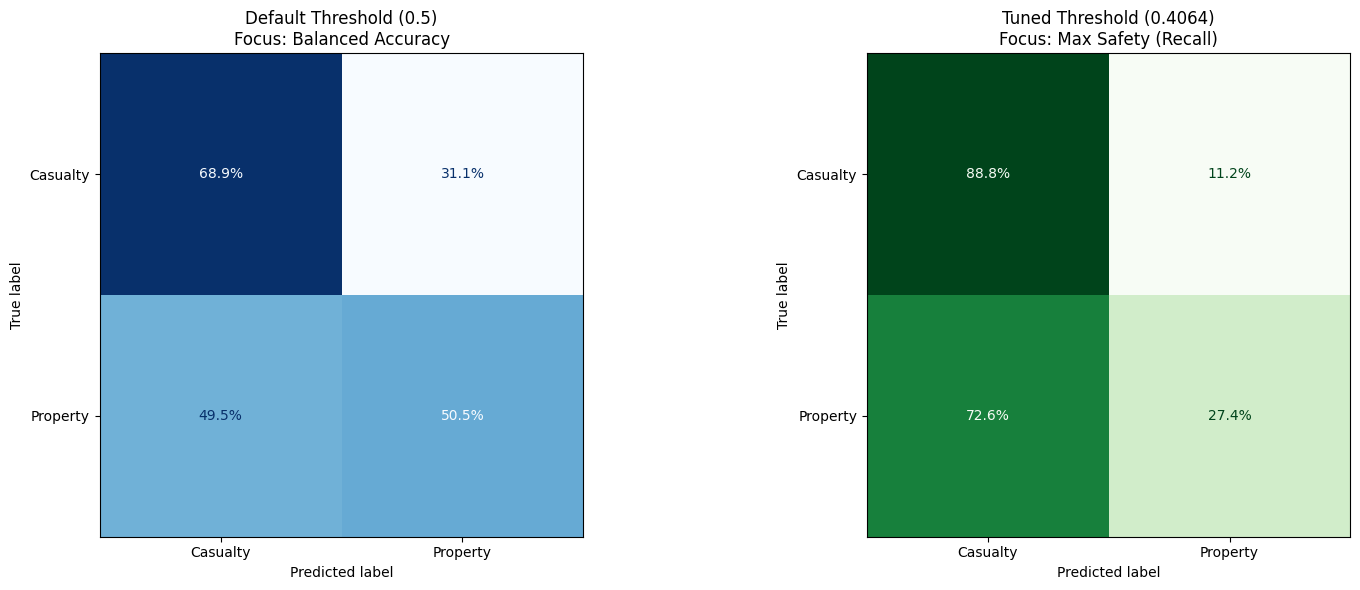

In [ ]:
# 1. Generate unbiased probabilities using Cross-Validation
# This ensures we tune the threshold on data the model hasn't seen during training
print("Generating cross-validated probabilities...")
y_scores_cv = cross_val_predict(
    best_lgbm, 
    X_train, 
    y_train_encoded, 
    cv=5, 
    method='predict_proba', 
    n_jobs=-1
)[:, 0] # Extract probability for Class 0 (Casualty)

# 2. Find the Optimal Threshold
# Calculate precision and recall for all possible thresholds
precisions, recalls, thresholds = precision_recall_curve(y_train_encoded, y_scores_cv, pos_label=0)

# Calculate F1 score for each threshold to find the balance point
# F1 = 2 * (Precision * Recall) / (Precision + Recall)
with np.errstate(divide='ignore', invalid='ignore'):
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls)

# Find the index of the maximum F1 score
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]
max_f1_score = f1_scores[best_idx]

# 3. Create Predictions for Comparison
# Default Threshold (0.5)
y_pred_default = np.where(y_scores_cv >= 0.5, 0, 1)

# Tuned Threshold (Optimal)
y_pred_tuned = np.where(y_scores_cv >= optimal_threshold, 0, 1)

# 4. Calculate Key Metrics
metrics = {
    'Default (0.5)': {
        'F1 Macro': f1_score(y_train_encoded, y_pred_default, average='macro'),
        'Casualty Recall': recall_score(y_train_encoded, y_pred_default, pos_label=0),
        'Casualty Precision': precision_recall_curve(y_train_encoded, y_scores_cv, pos_label=0)[0][np.searchsorted(thresholds, 0.5)] 
        # Note: Approximate precision for 0.5 from curve or recalculate manually
    },
    'Tuned ({:.4f})'.format(optimal_threshold): {
        'F1 Macro': f1_score(y_train_encoded, y_pred_tuned, average='macro'),
        'Casualty Recall': recall_score(y_train_encoded, y_pred_tuned, pos_label=0),
    }
}

# 5. Output Text Report
print("\n--- Threshold Optimization Results ---")
print(f"Optimal Threshold Found: {optimal_threshold:.4f}")
print(f"Max F1 (Casualty Class): {max_f1_score:.4f}")

print("\n--- Comparative Metrics ---")
print(f"Default F1 Macro: {metrics['Default (0.5)']['F1 Macro']:.4f}")
print(f"Tuned   F1 Macro: {metrics[list(metrics.keys())[1]]['F1 Macro']:.4f}")
print("-" * 30)
print(f"Default Casualty Recall: {metrics['Default (0.5)']['Casualty Recall']:.2%}")
print(f"Tuned   Casualty Recall: {metrics[list(metrics.keys())[1]]['Casualty Recall']:.2%}")

# 6. Visualize Confusion Matrices (Side-by-Side)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Default (Normalized by True Labels to show Recall %)
ConfusionMatrixDisplay.from_predictions(
    y_train_encoded, 
    y_pred_default, 
    display_labels=['Casualty', 'Property'],
    normalize='true',
    cmap='Blues',
    values_format='.1%',
    ax=axes[0],
    colorbar=False
)
axes[0].set_title('Default Threshold (0.5)\nFocus: Balanced Accuracy')

# Plot Tuned (Normalized by True Labels to show Recall %)
ConfusionMatrixDisplay.from_predictions(
    y_train_encoded, 
    y_pred_tuned, 
    display_labels=['Casualty', 'Property'],
    normalize='true',
    cmap='Greens',
    values_format='.1%',
    ax=axes[1],
    colorbar=False
)
axes[1].set_title(f'Tuned Threshold ({optimal_threshold:.4f})\nFocus: Max Safety (Recall)')

plt.tight_layout()
plt.show()

###  Why Prioritize Recall?

Given the project's goal of identifying risk factors to inform public policy, we explicitly prioritized **Recall** (sensitivity) over Precision. This decision is driven by three key factors:

1.  **Risk Latency ("Near Miss" Theory):**
    False Positives in this context - accidents classified as severe but resulting only in property damage—often represent high-risk scenarios that avoided casualties due to chance (aleatoric uncertainty). For safety analysis, identifying these "potential hazards" is as valuable as identifying actual casualties.

2.  **Cost Asymmetry:**
    The cost of a **False Negative** (overlooking a dangerous intersection or risk pattern) is unacceptably high, potentially leading to future loss of life due to lack of intervention. Conversely, the cost of a **False Positive** (investigating a safe location) is merely administrative.

3.  **Explainability Robustness:**
    To generate reliable policy recommendations using SHAP, the model must capture the widest possible variety of risk patterns. A high-recall threshold ensures that the subsequent feature importance analysis is based on a comprehensive set of dangerous scenarios, rather than just the most obvious ones.

## feature importent

#### SHAP Analysis
Now that we have a robust and calibrated model, we proceed to the project's primary objective: **understanding the factors contributing to severe crashes and deriving actionable policy.**

Complex models like LightGBM are often considered "black boxes." To unlock them and derive genuine insights, we will go beyond standard "Feature Importance" and utilize **SHAP Values**.

**What are we looking for?**
Unlike standard importance, which only tells us *which* features matter, SHAP reveals *how* they matter:
* **Directionality:** Does a high value in a feature (e.g., high speed) *increase* or *decrease* the probability of a severe crash?
* **Complexity:** Identifying non-linear relationships captured by the model.

In the following visualizations (specifically the Beeswarm Plot):
* **Red Color:** Indicates a high value of the feature.
* **Right Side (X-axis):** Indicates a positive contribution to the risk (pushing the prediction towards "Casualty").
This analysis will serve as the foundation for the Discussion and Recommendations chapter of our final report.

C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


SHAP output is a single array (Class 1). Inverting values to represent 'Casualty'.


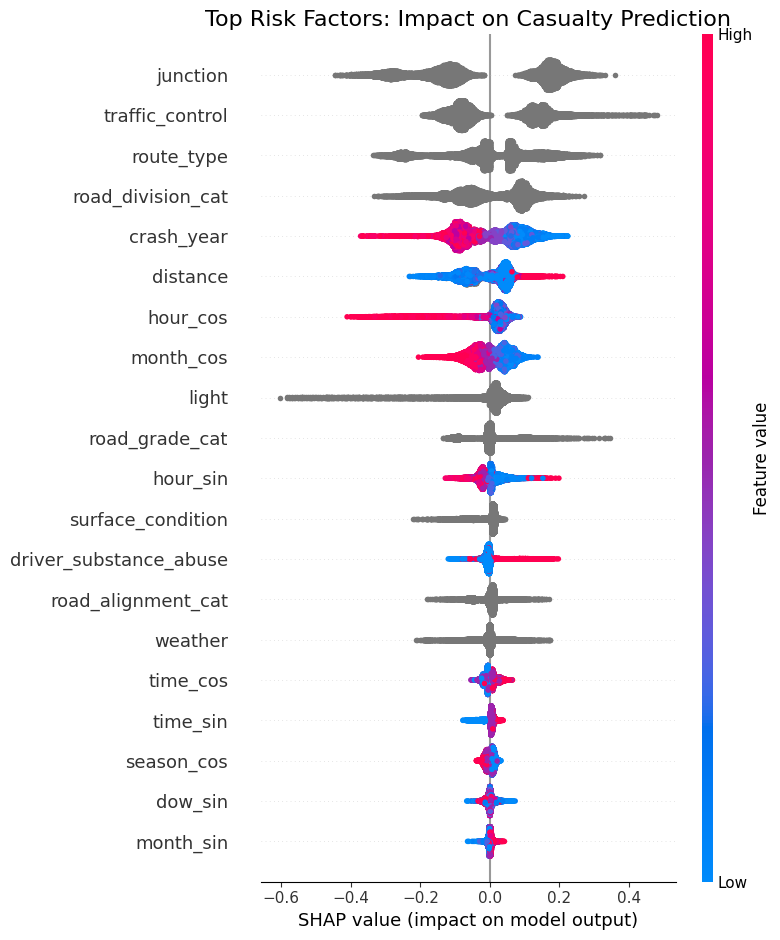

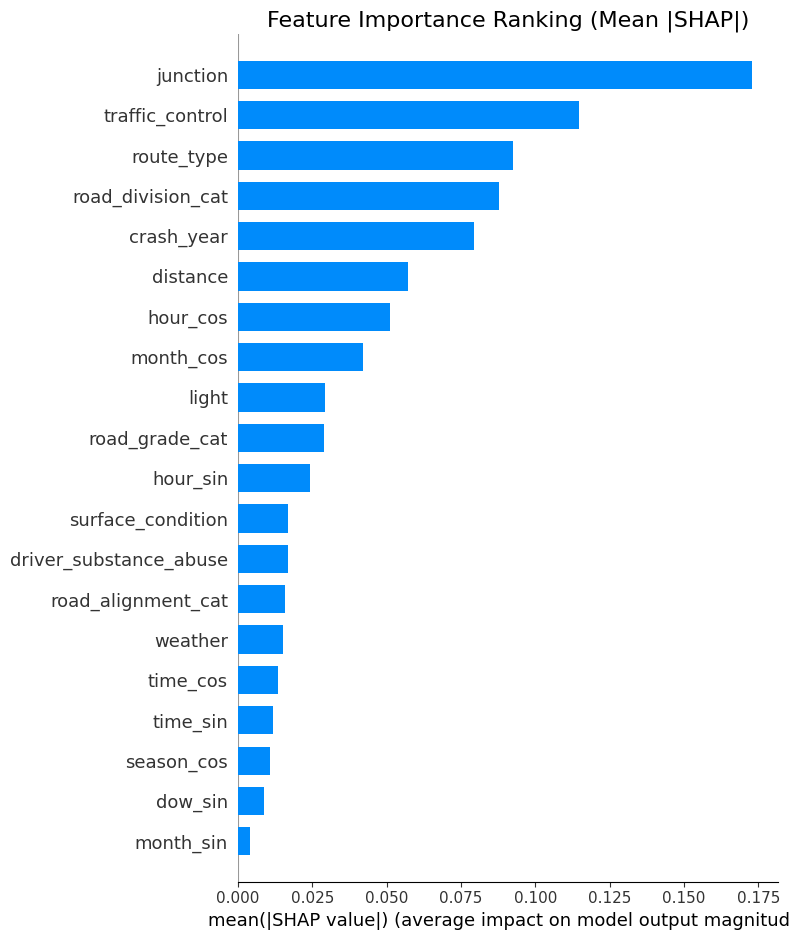

In [28]:
# 1. Prepare Data and Model components
# Extract the preprocessor and the model from the pipeline
preprocessor = best_lgbm.named_steps['preprocessor']
model = best_lgbm.named_steps['model']

# Transform the test set to get the features in the format the model expects
# Since transform_output="pandas" is set, this returns a DataFrame with column names
X_test_transformed = preprocessor.transform(X_test)

# Verify feature names extraction for clear plotting
if hasattr(X_test_transformed, "columns"):
    feature_names = X_test_transformed.columns
else:
    feature_names = preprocessor.get_feature_names_out()

# 2. Create SHAP Explainer
# TreeExplainer is optimized for tree-based models like LightGBM
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

# 3. Select the Correct Class (Casualty = 0)
# SHAP output format depends on the library version and model type (binary vs multiclass).
# We need to ensure we are visualizing the contribution towards Class 0 (Casualty).

if isinstance(shap_values, list):
    # If output is a list, it usually contains [matrix_class_0, matrix_class_1]
    print(f"SHAP output is a list. Selecting index 0 for 'Casualty'.")
    shap_values_target = shap_values[0]
else:
    # If output is a single array, it typically represents the log-odds for the Positive Class (1).
    # Since Class 1 is 'Property', high values mean 'Safe'.
    # We want to explain 'Casualty' (Risk), so we invert the values (-1 * values).
    print("SHAP output is a single array (Class 1). Inverting values to represent 'Casualty'.")
    shap_values_target = -1 * shap_values

# 4. Generate Summary Plot (Beeswarm)
# This plot shows the direction and magnitude of feature impact
plt.figure(figsize=(12, 10))
plt.title("Top Risk Factors: Impact on Casualty Prediction", fontsize=16)
shap.summary_plot(
    shap_values_target, 
    X_test_transformed, 
    feature_names=feature_names,
    max_display=20, 
    show=False
)
plt.tight_layout()
plt.show()

# 5. Generate Bar Plot (Mean Absolute Importance)
# This plot shows the overall importance of features (magnitude only)
plt.figure(figsize=(10, 8))
plt.title("Feature Importance Ranking (Mean |SHAP|)", fontsize=16)
shap.summary_plot(
    shap_values_target, 
    X_test_transformed, 
    feature_names=feature_names, 
    plot_type="bar",
    max_display=20, 
    show=False
)
plt.tight_layout()
plt.show()

C:\Users\אליאור\AppData\Local\Temp\ipykernel_16136\930943053.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_risk = analysis_df.groupby('Category')['SHAP_Value'].mean().sort_values(ascending=False)
C:\Users\אליאור\AppData\Local\Temp\ipykernel_16136\930943053.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_risk = analysis_df.groupby('Category')['SHAP_Value'].mean().sort_values(ascending=False)
C:\Users\אליאור\AppData\Local\Temp\ipykernel_16136\930943053.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass o

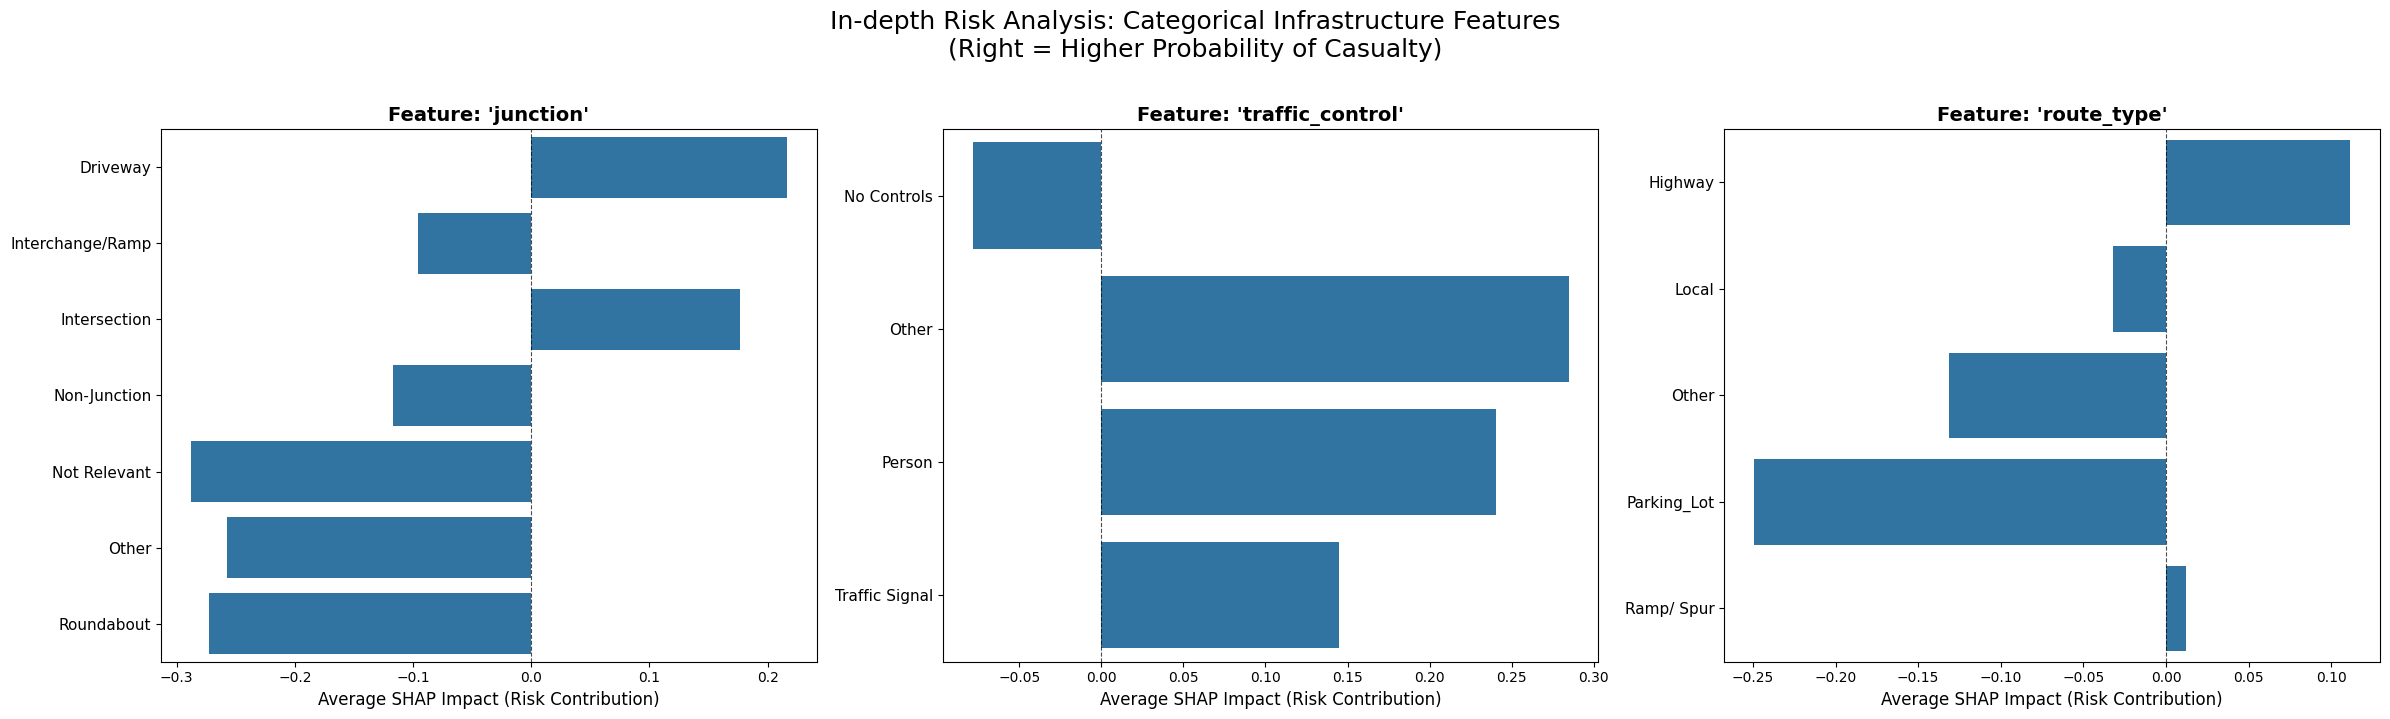

In [34]:
# 1. Define features to analyze
features_to_analyze = ['junction', 'traffic_control', 'route_type']

# 2. Setup the figure with subplots arranged in a single row
num_features = len(features_to_analyze)
fig, axes = plt.subplots(1, num_features, figsize=(24, 7), sharey=False)
fig.suptitle("In-depth Risk Analysis: Categorical Infrastructure Features\n(Right = Higher Probability of Casualty)", fontsize=18, y=1.02)

# 3. Loop through features and create a plot for each ax
for i, feature in enumerate(features_to_analyze):
    ax = axes[i] # Select current subplot axis
    
    # --- Data Preparation (Same logic as before) ---
    # Find feature index in SHAP data
    try:
        feature_idx = list(feature_names).index(feature)
    except ValueError:
        ax.text(0.5, 0.5, f"Feature '{feature}' not found in model input", 
                ha='center', va='center', transform=ax.transAxes)
        continue

    # Create DataFrame mapping raw categories to SHAP impact
    analysis_df = pd.DataFrame({
        'Category': X_test[feature].values,
        'SHAP_Value': shap_values_target[:, feature_idx]
    })
    
    # Calculate mean risk per category and sort
    category_risk = analysis_df.groupby('Category')['SHAP_Value'].mean().sort_values(ascending=False)
    
    
    sns.barplot(
        x=category_risk.values, 
        y=category_risk.index, 
        ax=ax # Draw on the current subplot
    )
    
    # Add reference line and format
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.set_title(f"Feature: '{feature}'", fontsize=14, fontweight='bold')
    ax.set_xlabel('Average SHAP Impact (Risk Contribution)', fontsize=12)
    ax.set_ylabel('') # Hide Y label to save space (categories are self-explanatory)
    ax.tick_params(axis='y', labelsize=11)

# 4. Finalize Layout
plt.tight_layout()
plt.show()